# 22 — Evaluate Face Model

Loads the best checkpoint for each trained face model and runs full test-set
evaluation: classification report, confusion matrix, and inference speed.

**Predictions are utterance-level**: softmax probabilities from the K frame
crops of each utterance are averaged before argmax.

**Depends on:** `12_train_face_model.ipynb` having been run.

**Reads from** `../experiments/face_unimodal/<version>/<model_slug>/model/`.

**Writes to each run directory:**
- `classification_report_test.json`
- `confusion_matrix_test.png`
- `eval_metrics.json`

In [1]:
import os
import sys

_here = os.path.abspath(os.getcwd())
_root = _here if os.path.isdir(os.path.join(_here, 'src')) else os.path.abspath(os.path.join(_here, '..'))
if _root not in sys.path:
    sys.path.insert(0, _root)

In [2]:
import pandas as pd

from src.config import (
    DEVICE, FACE_MODELS_TO_RUN, EXP_ROOT_FACE, VERSION,
    FACE_USE_CACHE, FACE_CACHE_DIR,
)
from src.data.face_dataset import load_face_metadata, ID2LABEL
from src.evaluation.evaluate_face import run_full_face_evaluation
from src.training.utils import slugify

## Load test metadata

In [3]:
test_df = load_face_metadata('test', version=VERSION)
print(f'Test frames : {len(test_df)}')
print(f'Test utterances : {test_df[["dialogue_id","utterance_id"]].drop_duplicates().shape[0]}')

Test frames : 12117
Test utterances : 2481


## Discover run directories

In [4]:
def find_run_dir(model_name: str) -> str:
    slug = slugify(model_name)
    path = os.path.join(EXP_ROOT_FACE, VERSION, slug)
    assert os.path.isdir(path), (
        f'Run directory not found: {path}\n'
        'Run 12_train_face_model.ipynb first.'
    )
    return path

run_dirs = [find_run_dir(m) for m in FACE_MODELS_TO_RUN]
print('Evaluating:', run_dirs)

Evaluating: ['../experiments/face_unimodal\\v1\\vit_b_16', '../experiments/face_unimodal\\v1\\mobilenet_v3_small']


## Run evaluation

In [5]:
all_results = {}

for model_name, run_dir in zip(FACE_MODELS_TO_RUN, run_dirs):
    print(f'\n=== {model_name} ===')
    results = run_full_face_evaluation(
        run_dir=run_dir,
        test_df=test_df,
        device=DEVICE,
        use_cache=FACE_USE_CACHE,
        cache_dir=FACE_CACHE_DIR,
        version=VERSION,
    )
    all_results[model_name] = results


=== vit_b_16 ===
  Loading checkpoint from ../experiments/face_unimodal\v1\vit_b_16
  Accuracy    : 0.3426
  Macro F1    : 0.2389
  Weighted F1 : 0.3558
  Infer ms/sample: 15.01

=== mobilenet_v3_small ===
  Loading checkpoint from ../experiments/face_unimodal\v1\mobilenet_v3_small
  Accuracy    : 0.2378
  Macro F1    : 0.1826
  Weighted F1 : 0.2176
  Infer ms/sample: 0.48


## Side-by-side summary

In [6]:
summary = pd.DataFrame([
    {
        'model':        name,
        'accuracy':     r['accuracy'],
        'macro_f1':     r['macro_f1'],
        'weighted_f1':  r['weighted_f1'],
        'infer_ms_bs1': r['inference_ms_per_sample_bs1'],
        'n_utterances': r['num_test_utterances'],
    }
    for name, r in all_results.items()
])
summary

,model,accuracy,macro_f1,weighted_f1,infer_ms_bs1,n_utterances
0,vit_b_16,0.342604,0.238915,0.355840,15.013,2481
1,mobilenet_v3_small,0.237807,0.182575,0.217596,0.478,2481


## Confusion matrices

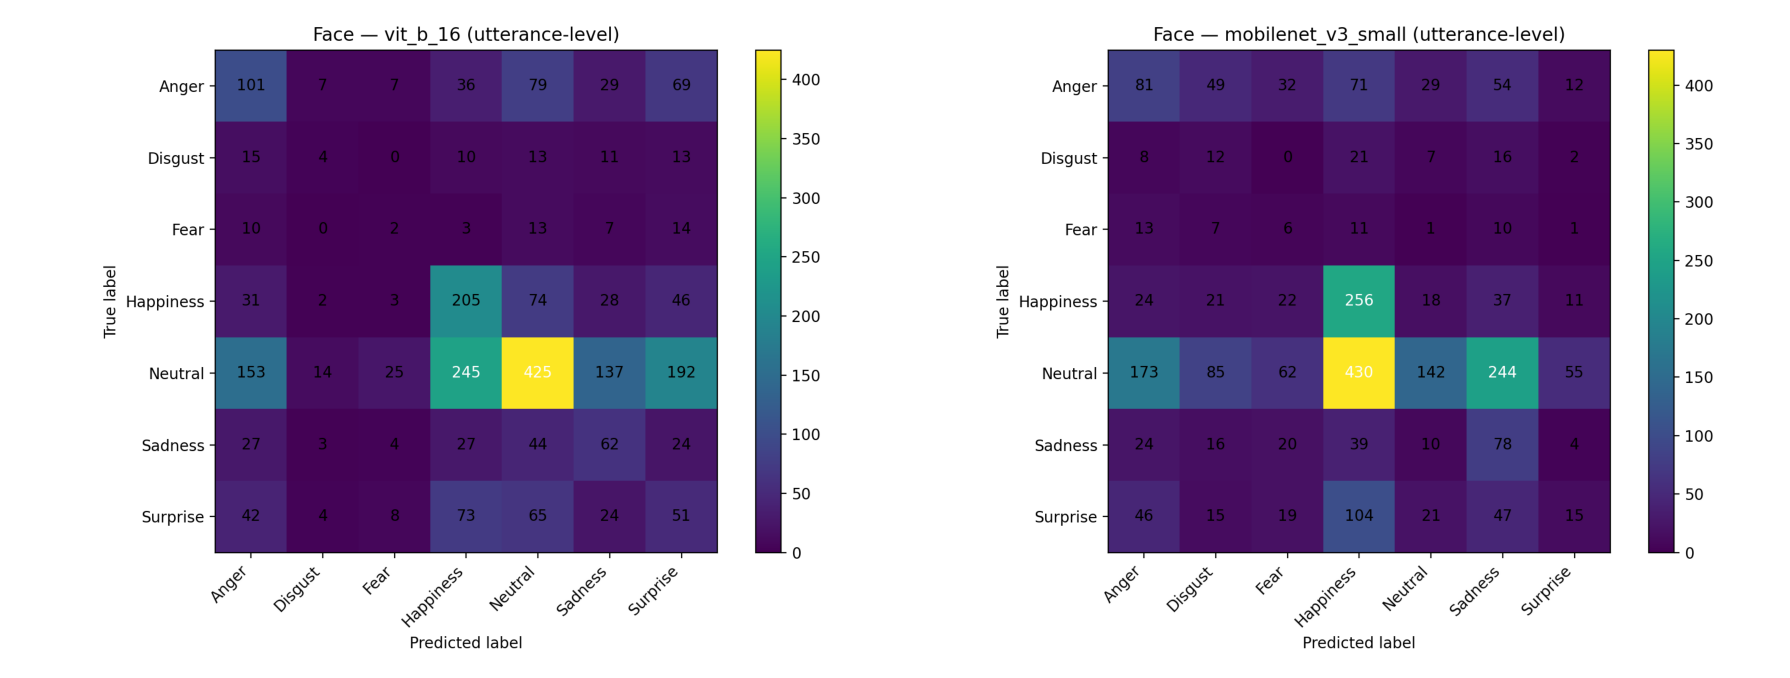

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, len(run_dirs), figsize=(9 * len(run_dirs), 7), squeeze=False)

for ax, run_dir in zip(axes[0], run_dirs):
    img_path = os.path.join(run_dir, 'confusion_matrix_test.png')
    if os.path.exists(img_path):
        ax.imshow(mpimg.imread(img_path))
    ax.axis('off')

plt.tight_layout()
plt.show()

## Per-class breakdown

In [8]:
import json

for model_name, run_dir in zip(FACE_MODELS_TO_RUN, run_dirs):
    report_path = os.path.join(run_dir, 'classification_report_test.json')
    if not os.path.exists(report_path):
        continue
    report = json.load(open(report_path))
    rows = [
        {
            'emotion':    cls,
            'precision':  round(v['precision'], 4),
            'recall':     round(v['recall'],    4),
            'f1-score':   round(v['f1-score'],  4),
            'support':    int(v['support']),
        }
        for cls, v in report.items()
        if isinstance(v, dict) and 'f1-score' in v
    ]
    print(f'\n--- {model_name} ---')
    display(pd.DataFrame(rows))


--- vit_b_16 ---


,emotion,precision,recall,f1-score,support
0,Anger,0.2665,0.3079,0.2857,328
1,Disgust,0.1176,0.0606,0.0800,66
2,Fear,0.0408,0.0408,0.0408,49
3,Happiness,0.3422,0.5270,0.4150,389
4,Neutral,0.5961,0.3568,0.4464,1191
5,Sadness,0.2081,0.3246,0.2536,191
6,Surprise,0.1247,0.1910,0.1509,267
7,macro avg,0.2423,0.2584,0.2389,2481
8,weighted avg,0.4084,0.3426,0.3558,2481



--- mobilenet_v3_small ---


,emotion,precision,recall,f1-score,support
0,Anger,0.2195,0.2470,0.2324,328
1,Disgust,0.0585,0.1818,0.0886,66
2,Fear,0.0373,0.1224,0.0571,49
3,Happiness,0.2747,0.6581,0.3876,389
4,Neutral,0.6228,0.1192,0.2001,1191
5,Sadness,0.1605,0.4084,0.2304,191
6,Surprise,0.1500,0.0562,0.0817,267
7,macro avg,0.2176,0.2562,0.1826,2481
8,weighted avg,0.4019,0.2378,0.2176,2481
